***Basic Guest Demographics***

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
data = pd.read_csv("../data/guest_survey_data.csv")
data

,guest_id,age,family_size,first_visit,visit_frequency,visit_motivation,venue,education_program,spending,satisfaction,learning_score,likelihood_return,likelihood_recommend,participated_booth
0,10001,56,3,no,First visit,Entertainment,Garden,No,14.617588,5.0,1.0,5.0,5.0,5
1,10002,69,5,no,Quarterly,Entertainment,Curiosity Museum,Yes,11.742618,5.0,3.0,5.0,5.0,5
2,10003,46,4,yes,Quarterly,Exhibits,Farm,No,15.875554,5.0,3.0,5.0,5.0,3
3,10004,32,5,no,Quarterly,Education,Farm,Yes,5.942116,4.0,2.0,3.0,4.0,3
4,10005,60,5,no,First visit,Family Time,Garden,No,9.851911,4.0,2.0,4.0,4.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,11196,23,6,no,First visit,Nature,Dinosaurs,No,6.918145,5.0,2.0,5.0,4.0,5
1196,11197,43,5,no,First visit,Family Time,Curiosity Museum,No,4.196820,5.0,3.0,4.0,5.0,1
1197,11198,71,6,no,First visit,Family Time,Dinosaurs,Yes,0.000000,5.0,3.0,5.0,4.0,5
1198,11199,21,3,no,First visit,Education,Garden,No,14.380630,4.0,3.0,5.0,4.0,2


In [60]:
##Age info
data["age"].describe()

count    1200.000000
mean       46.317500
std        16.451157
min        18.000000
25%        33.000000
50%        46.000000
75%        61.000000
max        74.000000
Name: age, dtype: float64

In [61]:
##Family Size Info
data["family_size"].value_counts().sort_index()

family_size
1    110
2     67
3    222
4    330
5    243
6    167
7     49
8     12
Name: count, dtype: int64

In [62]:
##First Time Visitor
data["first_visit"].value_counts(normalize=True) * 100

first_visit
no     66.5
yes    33.5
Name: proportion, dtype: float64

In [63]:
##Venue
data["venue"].value_counts()

venue
Garden              273
Events              252
Curiosity Museum    231
Dinosaurs           223
Farm                221
Name: count, dtype: int64

In [64]:
##Motivation
data["visit_motivation"].value_counts()

visit_motivation
Family Time      225
Exhibits         204
Education        203
Nature           198
Entertainment    187
Special Event    183
Name: count, dtype: int64

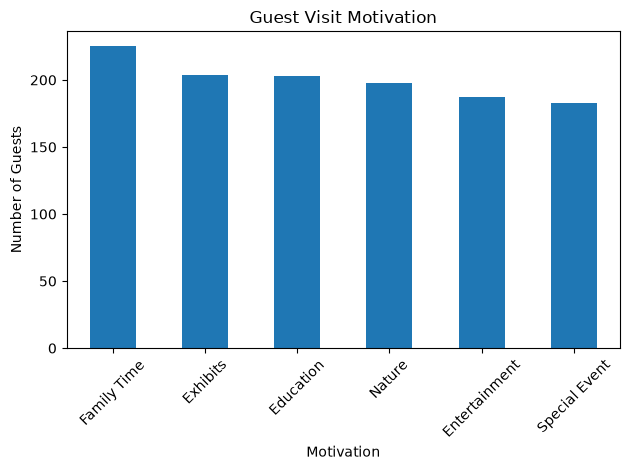

In [65]:
##Visualization
data["visit_motivation"].value_counts().plot(kind="bar")

plt.title("Guest Visit Motivation")
plt.xlabel("Motivation")
plt.ylabel("Number of Guests")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Q1.What makes guests satisfied?**

In [66]:
#Find a correlations first
numeric_columns = [
    "age",
    "family_size",
    "spending",
    "satisfaction",
    "learning_score",
    "likelihood_return",
    "likelihood_recommend",
    "participated_booth"
]
correlation = data[numeric_columns].corr()

correlation["satisfaction"].sort_values(
    ascending=False
)


satisfaction            1.000000
likelihood_return       0.804965
likelihood_recommend    0.802672
participated_booth      0.425048
family_size             0.011678
spending                0.011641
age                    -0.023497
learning_score         -0.034465
Name: satisfaction, dtype: float64

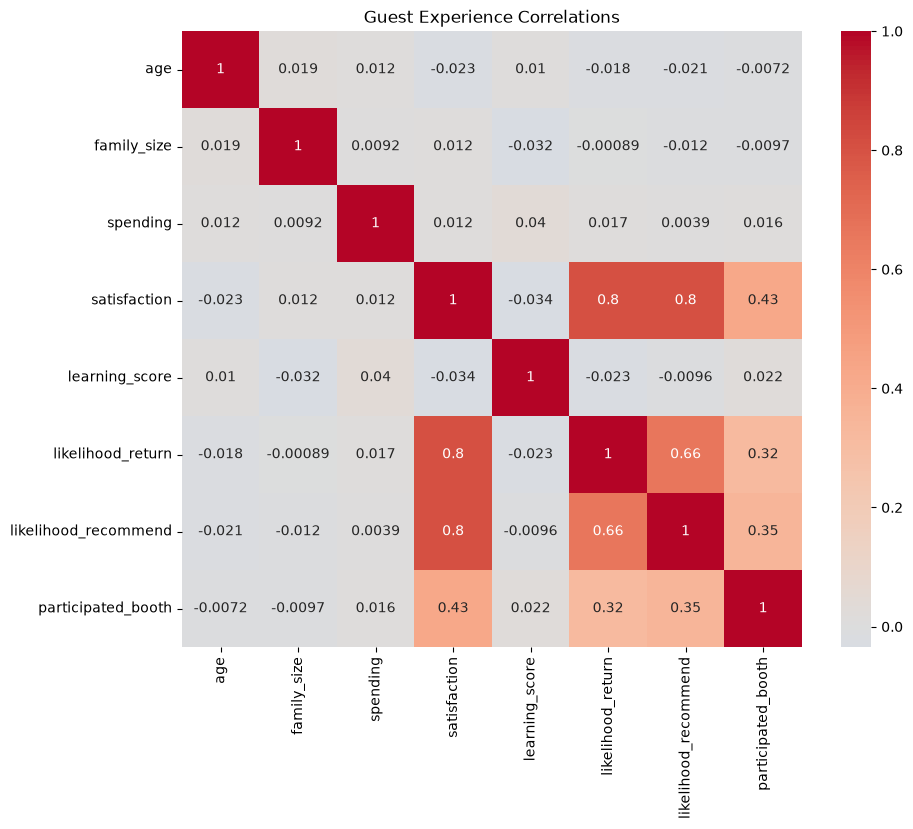

In [67]:
## 1. Heat Map Visualization
correlation = data.drop(columns=["guest_id"]).corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(correlation, annot=True, cmap="coolwarm", center=0)

plt.title("Guest Experience Correlations")

plt.show()



**Q1.What makes guests satisfied?**
- The number of guests participating booths are associated with higher guest satisfaction, suggesting that increasing guests participating booths may improve the guest experiences.

***Analyze Satisfaction by Venu***

In [68]:
venue_satisfaction = (
    data.groupby("venue")["satisfaction"]
    .mean()
    .sort_values(ascending=False)
)

venue_satisfaction


venue
Dinosaurs           4.367713
Garden              4.326007
Curiosity Museum    4.303030
Farm                4.280543
Events              4.277778
Name: satisfaction, dtype: float64

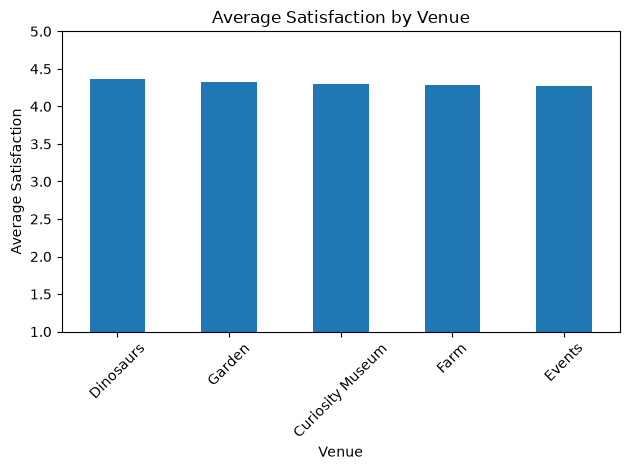

In [69]:
venue_satisfaction.plot(kind="bar")

plt.title("Average Satisfaction by Venue")
plt.ylabel("Average Satisfaction")
plt.xlabel("Venue")
plt.ylim(1, 5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The data and the graph shows the events are lower than other venues. 
It's possibly because:
- parking
- not enough space
- food
- ticketing
- bathrooms
- unclear signage
- program quality
- decoration quality